# **Imports**


In [ ]:
import os
!pip install opencv-python
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 17.9 MB/s eta 0:00:00


# **Setup**


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/data'
TRAIN_PATH   = os.path.join(DATASET_PATH, 'Train')
TEST_PATH    = os.path.join(DATASET_PATH, 'Test')
TRAIN_CSV    = os.path.join(DATASET_PATH, 'Train.csv')
TEST_CSV     = os.path.join(DATASET_PATH, 'Test.csv')

In [ ]:
IMG_SIZE      = (32, 32)        # al 7gm elgded
SELECTED_CLASSES = list(range(10))  # 3dd al class
SAMPLES_PER_CLASS = 80          # 3dd alimage per class
RANDOM_STATE  = 42

CLASS_NAMES = {
    0: 'Speed 20',    1: 'Speed 30',    2: 'Speed 50',
    3: 'Speed 60',    4: 'Speed 70',    5: 'Speed 80',
    6: 'End Speed 80',7: 'Speed 100',   8: 'Speed 120',
    9: 'No Passing'
}

# **1. Load Dataset (10 Classes)**

In [ ]:
def load_dataset(train_path, selected_classes, samples_per_class, img_size):
    """
    Load images from the Train folder.
    Returns:
        images_raw  : list of original BGR images (variable size)
        images      : np.array of resized grayscale images  (N, H, W)
        images_color: np.array of resized BGR images         (N, H, W, 3)
        labels      : np.array of integer class ids
    """
    images_raw   = []
    images       = []
    images_color = []
    labels       = []

    for cls in selected_classes:
        cls_path = os.path.join(train_path, str(cls))
        files    = sorted(os.listdir(cls_path))[:samples_per_class]
        for fname in files:
            fpath = os.path.join(cls_path, fname)
            img   = cv2.imread(fpath)
            if img is None:
                continue
            images_raw.append(img)
            img_resized       = cv2.resize(img, img_size)
            img_gray          = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
            images_color.append(img_resized)
            images.append(img_gray)
            labels.append(cls)

    return (
        images_raw,
        np.array(images),
        np.array(images_color),
        np.array(labels)
    )

images_raw, images, images_color, labels = load_dataset(
    TRAIN_PATH, SELECTED_CLASSES, SAMPLES_PER_CLASS, IMG_SIZE
)

print(f' Loaded {len(images)} images')
print(f'   Grayscale shape : {images.shape}')
print(f'   Color shape     : {images_color.shape}')
print(f'   Labels shape    : {labels.shape}')

 Loaded 800 images
   Grayscale shape : (800, 32, 32)
   Color shape     : (800, 32, 32, 3)
   Labels shape    : (800,)


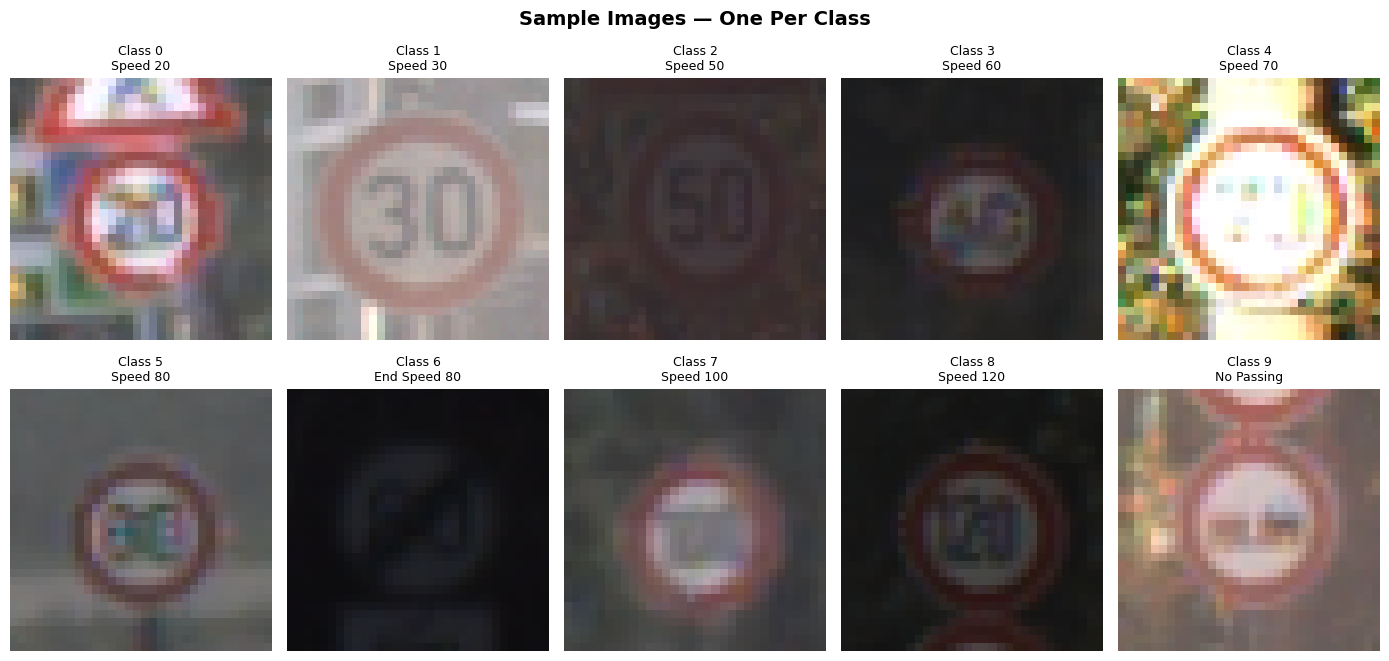

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(14, 7))
fig.suptitle('Sample Images — One Per Class', fontsize=14, fontweight='bold')
for i, cls in enumerate(SELECTED_CLASSES):
    idx = np.where(labels == cls)[0][0]
    ax  = axes[i // 5][i % 5]
    ax.imshow(cv2.cvtColor(images_color[idx], cv2.COLOR_BGR2RGB))
    ax.set_title(f'Class {cls}\n{CLASS_NAMES[cls]}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

# **Gaussian vs Median Filter**


In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def apply_filters(img_gray):
    """Apply Gaussian and Median filters to a grayscale image."""
    gaussian = cv2.GaussianBlur(img_gray, (5, 5), 0)
    median   = cv2.medianBlur(img_gray, 5)
    return gaussian, median

def compute_metrics(original, filtered):
    """Compute PSNR and SSIM between original and filtered images."""
    p = psnr(original, filtered, data_range=255)
    s = ssim(original, filtered, data_range=255)
    return p, s

# **Visual comparison on 3 sample images**

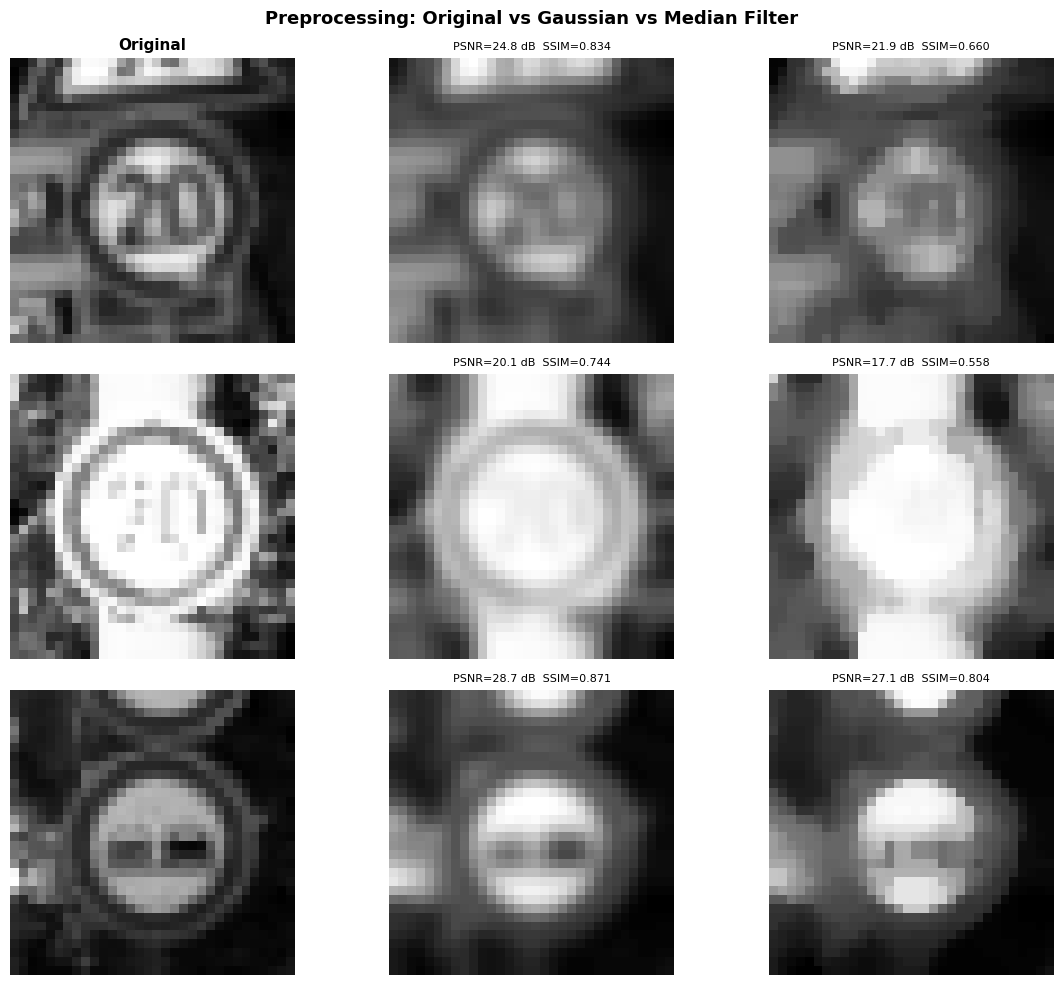

In [ ]:
sample_indices = [np.where(labels == c)[0][5] for c in [0, 4, 9]]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Preprocessing: Original vs Gaussian vs Median Filter', fontsize=13, fontweight='bold')
col_titles = ['Original', 'Gaussian Filter (5×5)', 'Median Filter (5×5)']
for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=11, fontweight='bold')

psnr_gauss_all, psnr_med_all = [], []
ssim_gauss_all, ssim_med_all = [], []

for row, idx in enumerate(sample_indices):
    orig     = images[idx]
    gauss, med = apply_filters(orig)
    pg, sg   = compute_metrics(orig, gauss)
    pm, sm   = compute_metrics(orig, med)
    psnr_gauss_all.append(pg); psnr_med_all.append(pm)
    ssim_gauss_all.append(sg); ssim_med_all.append(sm)

    axes[row][0].imshow(orig, cmap='gray')
    axes[row][0].set_ylabel(CLASS_NAMES[labels[idx]], fontsize=9)
    axes[row][1].imshow(gauss, cmap='gray')
    axes[row][1].set_title(f'PSNR={pg:.1f} dB  SSIM={sg:.3f}', fontsize=8)
    axes[row][2].imshow(med, cmap='gray')
    axes[row][2].set_title(f'PSNR={pm:.1f} dB  SSIM={sm:.3f}', fontsize=8)
    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.show()

# **Numeric comparison**

In [ ]:
print('\n Average Filter Metrics Across Samples:')
print(f'   Gaussian → PSNR: {np.mean(psnr_gauss_all):.2f} dB  |  SSIM: {np.mean(ssim_gauss_all):.4f}')
print(f'   Median   → PSNR: {np.mean(psnr_med_all):.2f} dB  |  SSIM: {np.mean(ssim_med_all):.4f}')
print('\n Higher PSNR = less signal distortion')
print('   Higher SSIM = more structural similarity to original')


 Average Filter Metrics Across Samples:
   Gaussian → PSNR: 24.54 dB  |  SSIM: 0.8162
   Median   → PSNR: 22.21 dB  |  SSIM: 0.6739

 Higher PSNR = less signal distortion
   Higher SSIM = more structural similarity to original


# **Apply Gaussian filter to all images for pipeline**

In [ ]:
images_filtered = np.array([cv2.GaussianBlur(img, (5, 5), 0) for img in images])
print('\n Gaussian filter applied to all images for pipeline use')


 Gaussian filter applied to all images for pipeline use


# **Harris Corner Detection**

In [ ]:
def harris_corners(img_gray, block_size=2, ksize=3, k=0.04, threshold_ratio=0.01):
    """
    Detect Harris corners and return:
    - corner_img : image with corners marked in red
    - num_corners: count of detected corners
    """
    img_float  = np.float32(img_gray)
    dst        = cv2.cornerHarris(img_float, block_size, ksize, k)
    dst_norm   = cv2.dilate(dst, None)  # dilate for visibility
    threshold  = threshold_ratio * dst_norm.max()

    corner_img = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    corners    = np.argwhere(dst_norm > threshold)
    for y, x in corners:
        cv2.circle(corner_img, (x, y), 1, (0, 0, 255), -1)

    return corner_img, len(corners)

# **Visual: corners on 3 classes**

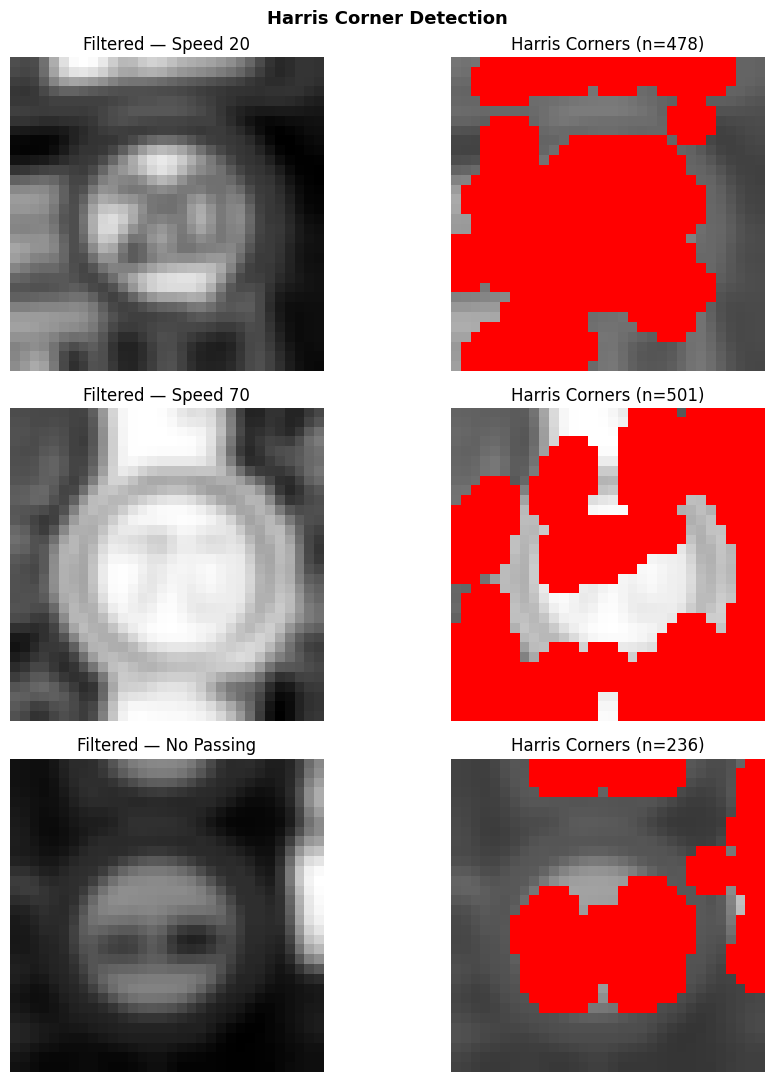

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(10, 11))
fig.suptitle('Harris Corner Detection', fontsize=13, fontweight='bold')
for row, cls in enumerate([0, 4, 9]):
    idx  = np.where(labels == cls)[0][10]
    orig = images_filtered[idx]
    c_img, n = harris_corners(orig)
    axes[row][0].imshow(orig, cmap='gray')
    axes[row][0].set_title(f'Filtered — {CLASS_NAMES[cls]}')
    axes[row][0].axis('off')
    axes[row][1].imshow(cv2.cvtColor(c_img, cv2.COLOR_BGR2RGB))
    axes[row][1].set_title(f'Harris Corners (n={n})')
    axes[row][1].axis('off')
plt.tight_layout()
plt.show()

# **Threshold tuning analysis**

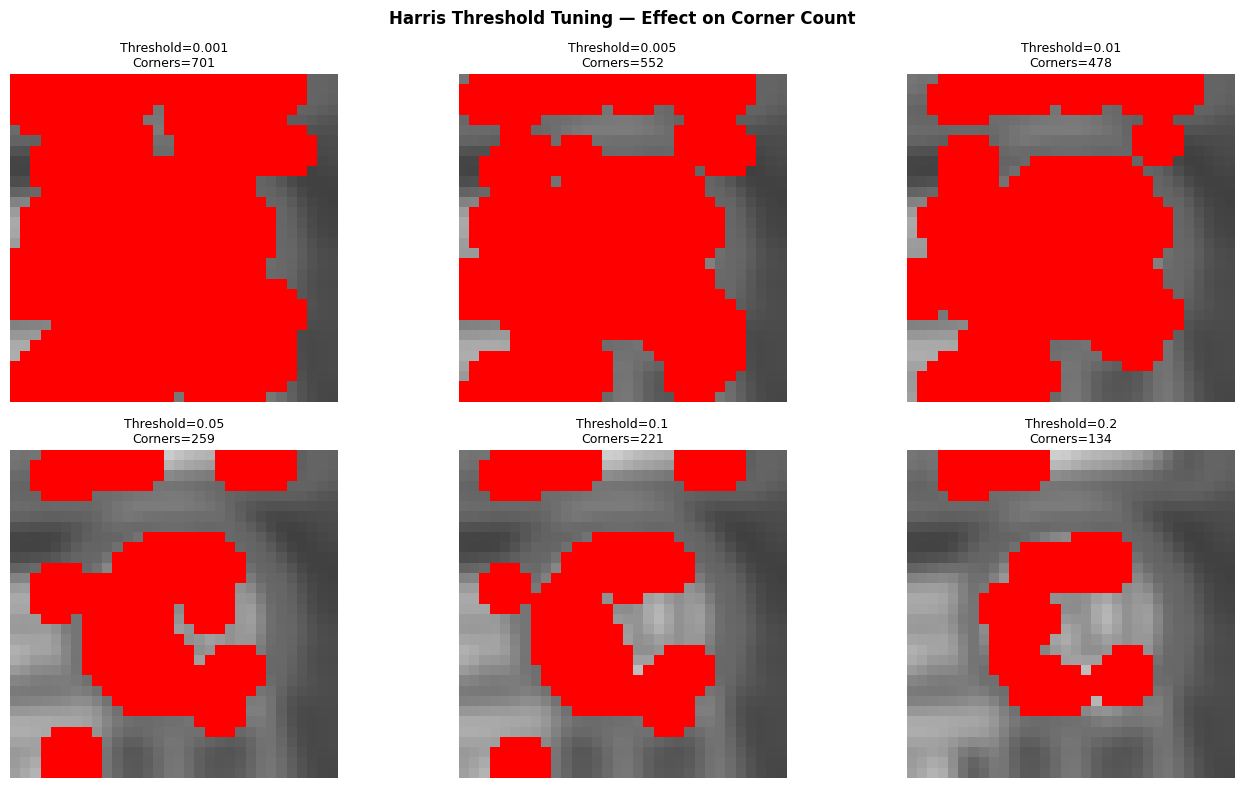

In [ ]:
thresholds  = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
idx_demo    = np.where(labels == 0)[0][10]
img_demo    = images_filtered[idx_demo]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Harris Threshold Tuning — Effect on Corner Count', fontsize=12, fontweight='bold')
for i, t in enumerate(thresholds):
    c_img, n = harris_corners(img_demo, threshold_ratio=t)
    ax = axes[i // 3][i % 3]
    ax.imshow(cv2.cvtColor(c_img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Threshold={t}\nCorners={n}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

# **Gaussian & Laplacian Pyramid**

In [ ]:
def build_gaussian_pyramid(img, levels=4):
    pyramid = [img.copy()]
    for _ in range(levels - 1):
        img = cv2.pyrDown(img)
        pyramid.append(img)
    return pyramid
def build_laplacian_pyramid(gp):
   """Build Laplacian Pyramid from Gaussian"""
   lp = []
   for i in range(len(gp) -1):
     size = (gp[i].shape[1], gp[i].shape[0])
     up = cv2.pyrUp(gp[i + 1], dstsize=size)
     lap = cv2.subtract(gp[i], up)
     lp.append(lap)
   lp.append(gp[-1])   # Top level = smallest Gaussian
   return lp

In [ ]:
idx_pyr = np.where(labels == 0)[0][20]
img_pyr = cv2.cvtColor(images_raw[idx_pyr], cv2.COLOR_BGR2GRAY)
img_pyr = cv2.resize(img_pyr, (128, 128))
g_pyr = build_gaussian_pyramid(img_pyr, levels=4)
l_pyr = build_laplacian_pyramid(g_pyr)

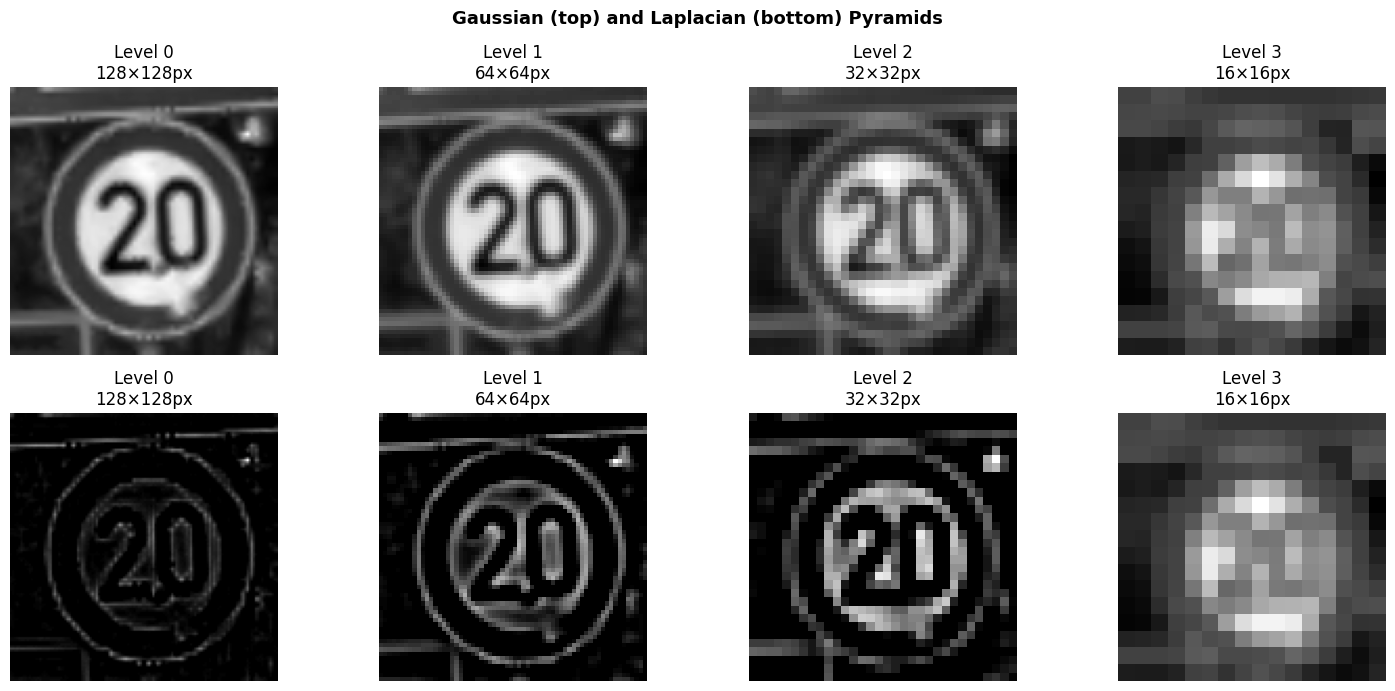

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
fig.suptitle('Gaussian (top) and Laplacian (bottom) Pyramids', fontsize=13, fontweight='bold')
labels_row = ['Gaussian Pyramid', 'Laplacian Pyramid']
for col in range(4):
    # Gaussian
    axes[0][col].imshow(g_pyr[col], cmap='gray')
    axes[0][col].set_title(f'Level {col}\n{g_pyr[col].shape[0]}×{g_pyr[col].shape[1]}px')
    axes[0][col].axis('off')
    # Laplacian
    lap_display = cv2.normalize(l_pyr[col], None, 0, 255, cv2.NORM_MINMAX)
    axes[1][col].imshow(lap_display, cmap='gray')
    axes[1][col].set_title(f'Level {col}\n{l_pyr[col].shape[0]}×{l_pyr[col].shape[1]}px')
    axes[1][col].axis('off')

axes[0][0].set_ylabel('Gaussian\nPyramid', fontsize=10, fontweight='bold')
axes[1][0].set_ylabel('Laplacian\nPyramid', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

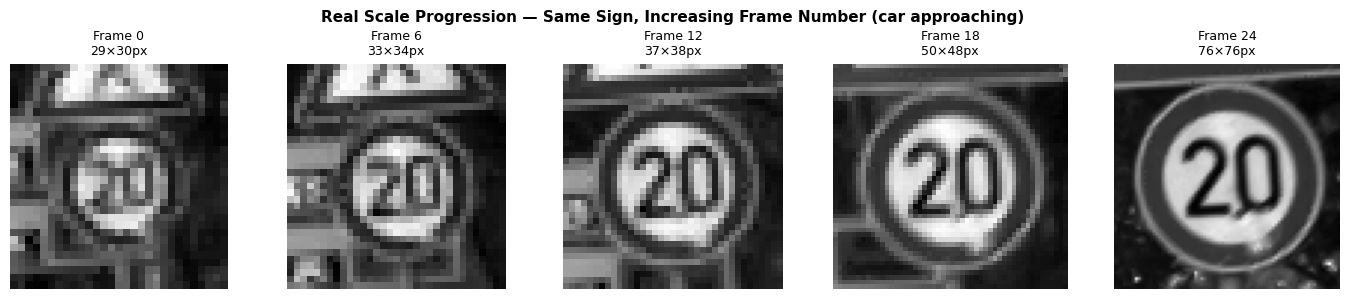

💡 These frames mirror what the pyramid does artificially — the same sign at different scales.


In [ ]:
# ── Connect to track frames: same sign at multiple scales ─────────────────
# Load first 5 frames of class 0, track 0 to show real scale progression
track_frames = []
cls0_path = os.path.join(TRAIN_PATH, '0')
track0_files = sorted([f for f in os.listdir(cls0_path) if f.startswith('00000_00000_')])
step = max(1, len(track0_files) // 5)
sampled = track0_files[::step][:5]
for fname in sampled:
    img = cv2.imread(os.path.join(cls0_path, fname), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        track_frames.append((fname, img))

if track_frames:
    fig, axes = plt.subplots(1, len(track_frames), figsize=(14, 3))
    fig.suptitle('Real Scale Progression — Same Sign, Increasing Frame Number (car approaching)',
                 fontsize=11, fontweight='bold')
    for i, (fname, fr) in enumerate(track_frames):
        frame_id = fname.split('_')[2].replace('.png','')
        axes[i].imshow(fr, cmap='gray')
        axes[i].set_title(f'Frame {int(frame_id)}\n{fr.shape[1]}×{fr.shape[0]}px', fontsize=9)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
    print('💡 These frames mirror what the pyramid does artificially — the same sign at different scales.')

# **SIFT Feature Extraction & Matching**

In [ ]:
sift = cv2.SIFT_create()

# **Keypoint visualization on sample images**

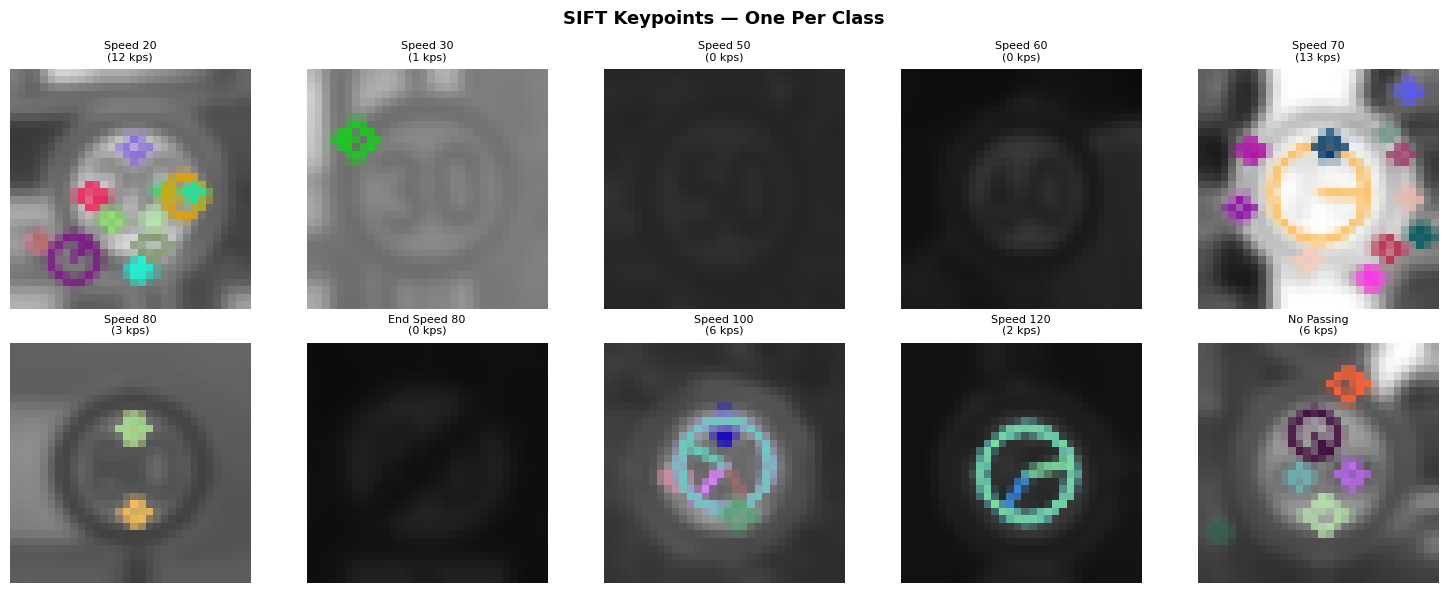

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('SIFT Keypoints — One Per Class', fontsize=13, fontweight='bold')
kp_counts = []
for i, cls in enumerate(SELECTED_CLASSES):
    idx  = np.where(labels == cls)[0][15]
    img  = images_filtered[idx]
    kps, _ = sift.detectAndCompute(img, None)
    kp_counts.append(len(kps))
    img_kp = cv2.drawKeypoints(img, kps, None,
                                flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    axes[i // 5][i % 5].imshow(img_kp)
    axes[i // 5][i % 5].set_title(f'{CLASS_NAMES[cls]}\n({len(kps)} kps)', fontsize=8)
    axes[i // 5][i % 5].axis('off')
plt.tight_layout()
plt.show()

# **Match keypoints between image pairs**

In [ ]:
path1='/content/drive/MyDrive/data/Train/0/00000_00000_00000.png'
path2='/content/drive/MyDrive/data/Train/0/00000_00006_00017.png'
img1=cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
img2=cv2.imread(path2, cv2.IMREAD_GRAYSCALE)



In [ ]:
# Detect SIFT features in both images
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)
# BFMatcher with L2 norm (suited for SIFT
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
matches = bf.knnMatch(des1, des2, k=2) # k=2 for ratio test
# Lowe's ratio test keep only strong matches
good_matches = []
for m, n in matches:
  if m.distance <0.75* n.distance:
    good_matches.append([m])
# Draw filtered matches between images
result = cv2.drawMatchesKnn(img1, kp1, img2, kp2,
good_matches, None,
flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
cv2.imwrite('matches.jpg', result)
print(f'Good matches: {len(good_matches)} / {len(matches)}')

Good matches: 1 / 17


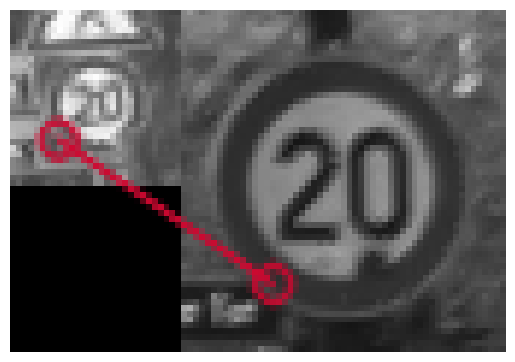


 Matching Accuracy (Lowe ratio test): 5.9%


In [ ]:
plt.imshow(result)
plt.axis('off')
plt.show()

matching_acc = len(good_matches) / max(len(matches), 1) * 100
print(f'\n Matching Accuracy (Lowe ratio test): {matching_acc:.1f}%')

# **Image Segmentation — K-Means**

In [ ]:
def segment_kmeans(img_color, K=3):
    """K-Means clustering segmentation."""
    Z       = img_color.reshape((-1, 3)).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels_km, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers   = np.uint8(centers)
    result    = centers[labels_km.flatten()].reshape(img_color.shape)
    # Return the dominant cluster mask (largest cluster)
    unique, counts = np.unique(labels_km, return_counts=True)
    dominant = unique[np.argmax(counts)]
    mask_km  = (labels_km.reshape(img_color.shape[:2]) == dominant).astype(np.uint8) * 255
    return mask_km, result

def compute_iou(mask_pred, bbox):
    """Compute IoU between binary mask and bounding box (x1,y1,x2,y2)."""
    x1, y1, x2, y2 = bbox
    gt_mask = np.zeros_like(mask_pred)
    gt_mask[y1:y2, x1:x2] = 255
    intersection = np.logical_and(mask_pred > 0, gt_mask > 0).sum()
    union        = np.logical_or(mask_pred > 0,  gt_mask > 0).sum()
    return intersection / union if union > 0 else 0


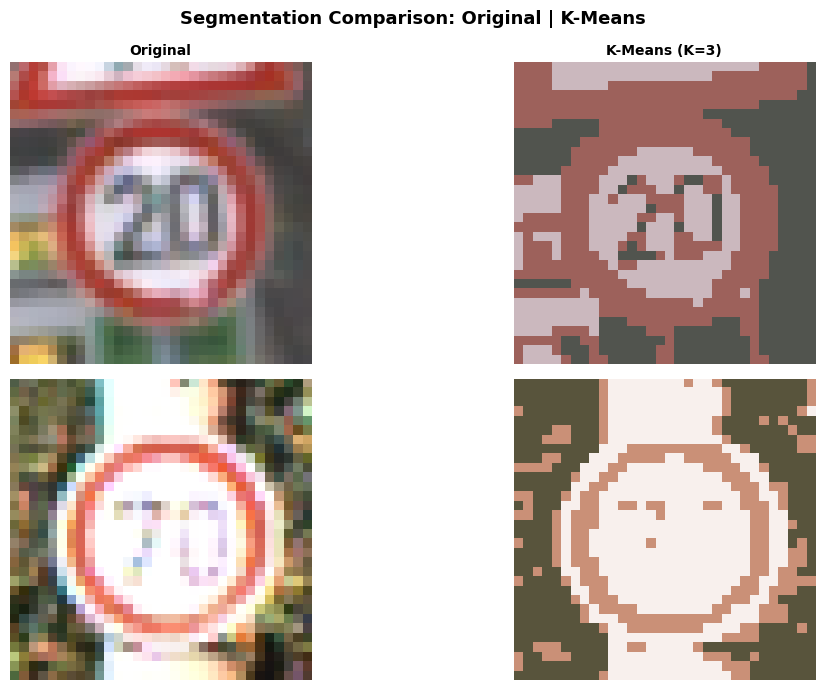

In [ ]:
sample_seg_cls = [0, 4]

fig, axes = plt.subplots(len(sample_seg_cls), 2, figsize=(12, 7))
fig.suptitle('Segmentation Comparison: Original | K-Means', fontsize=13, fontweight='bold')

col_titles = ['Original', 'K-Means (K=3)']

for col, t in enumerate(col_titles):
    axes[0][col].set_title(t, fontsize=10, fontweight='bold')

for row, cls in enumerate(sample_seg_cls):
    idx = np.where(labels == cls)[0][10]
    img_c = images_color[idx]
    img_c32 = cv2.resize(img_c, (32, 32))

    _, res_km = segment_kmeans(img_c32)

    # Original
    axes[row][0].imshow(cv2.cvtColor(img_c32, cv2.COLOR_BGR2RGB))
    axes[row][0].set_ylabel(CLASS_NAMES[cls], fontsize=9)

    # K-Means result
    axes[row][1].imshow(cv2.cvtColor(res_km, cv2.COLOR_BGR2RGB))

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
print('\n IoU Scores (K-Means only) using GT bounding boxes from Train.csv:')
print(f'{"Class":<15} {"K-Means IoU":>13}')
print('-' * 30)

for cls in SELECTED_CLASSES[:5]:
    cls_rows = train_df[train_df['ClassId'] == cls].head(10)

    ious_k = []

    for _, row_data in cls_rows.iterrows():
        fpath = os.path.join(DATASET_PATH, row_data['Path'])
        img = cv2.imread(fpath)
        if img is None:
            continue

        h, w = img.shape[:2]
        img32 = cv2.resize(img, (32, 32))

        x1 = int(row_data['Roi.X1'] * 32 / w)
        y1 = int(row_data['Roi.Y1'] * 32 / h)
        x2 = int(row_data['Roi.X2'] * 32 / w)
        y2 = int(row_data['Roi.Y2'] * 32 / h)

        _, mask_km = segment_kmeans(img32)

        ious_k.append(compute_iou(mask_km, (x1, y1, x2, y2)))

    print(f'{CLASS_NAMES[cls]:<15} {np.mean(ious_k):>13.4f}')


 IoU Scores (K-Means only) using GT bounding boxes from Train.csv:
Class             K-Means IoU
------------------------------
Speed 20               0.4395
Speed 30               0.6680
Speed 50               0.4901
Speed 60               0.3812
Speed 70               0.5886


# **Feature Extraction for Classification**

In [ ]:
from skimage.feature import hog

def extract_hog_features(img_gray):
    """Extract HOG features from a grayscale image."""
    features, _ = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True
    )
    return features

def extract_color_histogram(img_color, bins=32):
    """Extract concatenated HSV color histogram."""
    hsv  = cv2.cvtColor(img_color, cv2.COLOR_BGR2HSV)
    hist = []
    for ch in range(3):
        h = cv2.calcHist([hsv], [ch], None, [bins], [0, 256])
        hist.append(h.flatten())
    return np.concatenate(hist)

print('  Extracting features from all images...')
hog_features   = np.array([extract_hog_features(img)   for img in images_filtered])
color_features = np.array([extract_color_histogram(img) for img in images_color])
combined_features = np.hstack([hog_features, color_features])


  Extracting features from all images...


# **Train / Test split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(combined_features, labels,test_size=0.2, random_state=RANDOM_STATE, stratify=labels)

# **Scale features**

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)



# **Training Naive Bayes**

In [ ]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_sc, y_train)
nb_preds = nb_clf.predict(X_test_sc)

# **Metric helper**

In [ ]:
def print_metrics( y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'\n── Naive Bayes ──')
    print(f'   Accuracy : {acc * 100:.2f}%')
    print(f'   Precision: {prec * 100:.2f}%')
    print(f'   Recall   : {rec * 100:.2f}%')
    return acc, prec, rec

nb_acc, nb_prec, nb_rec  = print_metrics( y_test, nb_preds)


── Naive Bayes ──
   Accuracy : 95.62%
   Precision: 95.74%
   Recall   : 95.62%


# **Per-class report**

In [ ]:
print('\nNaive Bayes — Classification Report:')
print(classification_report(y_test, nb_preds,
      target_names=[CLASS_NAMES[c] for c in SELECTED_CLASSES]))


Naive Bayes — Classification Report:
              precision    recall  f1-score   support

    Speed 20       1.00      0.94      0.97        16
    Speed 30       0.94      1.00      0.97        16
    Speed 50       1.00      1.00      1.00        16
    Speed 60       0.94      0.94      0.94        16
    Speed 70       1.00      0.94      0.97        16
    Speed 80       0.94      0.94      0.94        16
End Speed 80       1.00      1.00      1.00        16
   Speed 100       0.88      0.94      0.91        16
   Speed 120       0.88      0.88      0.88        16
  No Passing       1.00      1.00      1.00        16

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160



# **Confusion matrices**

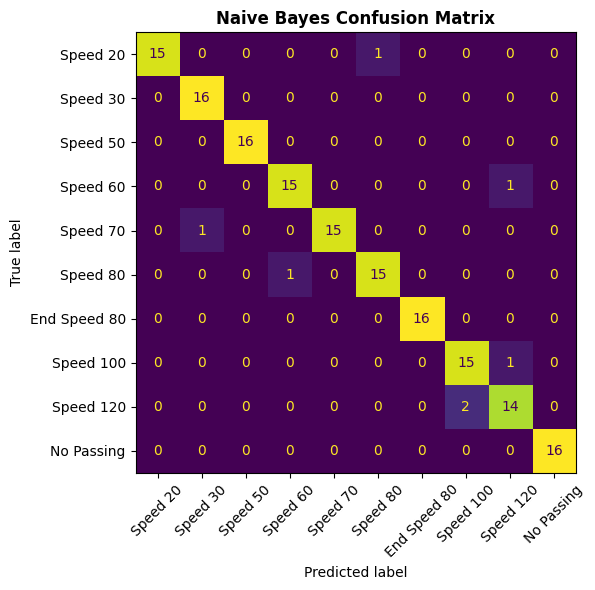

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

cm = confusion_matrix(y_test, nb_preds)
disp = ConfusionMatrixDisplay(
    cm,
    display_labels=[CLASS_NAMES[c] for c in SELECTED_CLASSES]
)

disp.plot(ax=ax, colorbar=False, xticks_rotation=45)

ax.set_title('Naive Bayes Confusion Matrix', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# **Full Integrated Pipeline**

In [ ]:
def full_pipeline(img_bgr, classifier, scaler, verbose=True):
    """
    End-to-end pipeline for a single image:
    1. Preprocess
    2. Harris corners
    3. Pyramid
    4. SIFT
    5. Segment
    6. Extract features
    7. Classify
    Returns: predicted class id, visualization figure
    """
    img_resized   = cv2.resize(img_bgr, IMG_SIZE)
    img_gray      = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # Step 1 — Preprocessing
    img_filtered  = cv2.GaussianBlur(img_gray, (5, 5), 0)

    # Step 2 — Harris
    corner_img, n_corners = harris_corners(img_filtered)

    # Step 3 — Pyramid
    g_pyr = build_gaussian_pyramid(img_filtered, levels=3)
    # Step 4 — SIFT
    kps, _  = sift.detectAndCompute(img_filtered, None)
    img_kp  = cv2.drawKeypoints(img_filtered, kps, None,
                                 flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # Step 5 — Segmentation (K-means)
    mask_t, seg_result = segment_kmeans(img_resized)

    # Step 6 — Features
    hog_feat   = extract_hog_features(img_filtered)
    color_feat = extract_color_histogram(img_resized)
    feat_vec   = scaler.transform([np.hstack([hog_feat, color_feat])])

    # Step 7 — Classify
    pred_class = classifier.predict(feat_vec)[0]

    # ── Visualization ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 7, figsize=(18, 5))

    steps = [
       (img_resized,   'BGR',   '1. Original'),
       (img_filtered,  'gray',  '2. Gaussian Filter'),
       (corner_img,    'BGR',   f'3. Harris ({n_corners} corners)'),
       (g_pyr[1],      'gray',  '4. Pyramid L1'),
       (img_kp,        'gray',  f'5. SIFT ({len(kps)} kps)'),
       (mask_t,        'gray',  '6. Segment Mask'),
       (seg_result,    'BGR',   '7. Seg Result'),
            ]

    for ax, (img, mode, title) in zip(axes, steps):
      if mode == 'BGR':
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
      else:
        ax.imshow(img, cmap='gray')
      ax.set_title(title, fontsize=9, fontweight='bold')
      ax.axis('off')

    plt.tight_layout()
    plt.show()
    return pred_class

# **Run on 5 test samples**

  RUNNING FULL INTEGRATED PIPELINE ON TEST SAMPLES


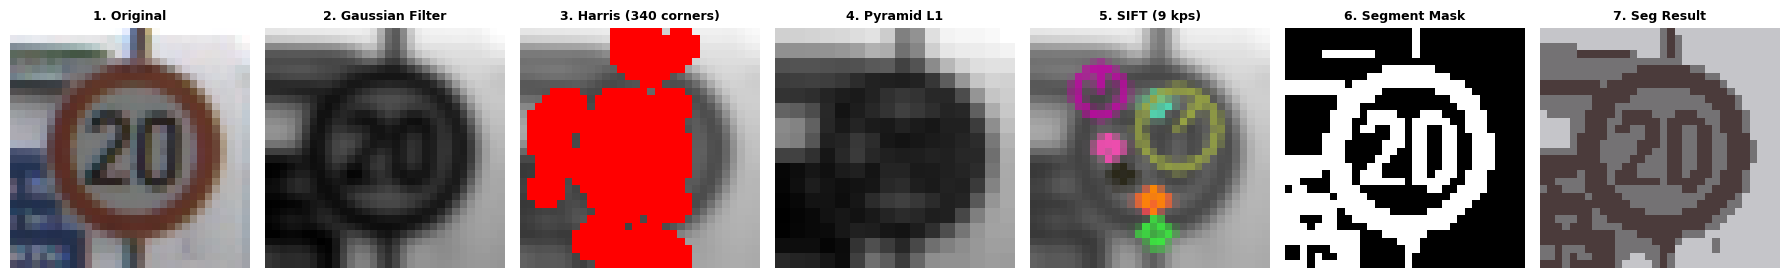

✅ True: Speed 20        Predicted: Speed 20



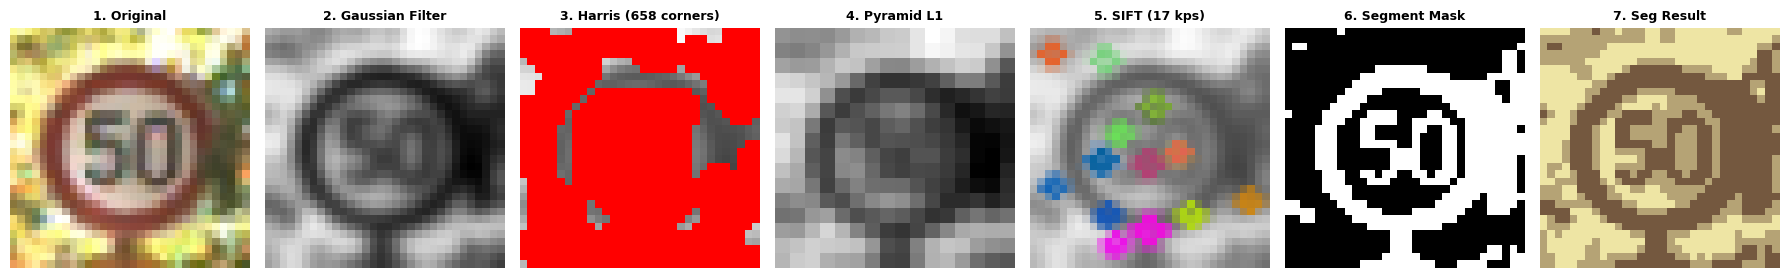

✅ True: Speed 50        Predicted: Speed 50



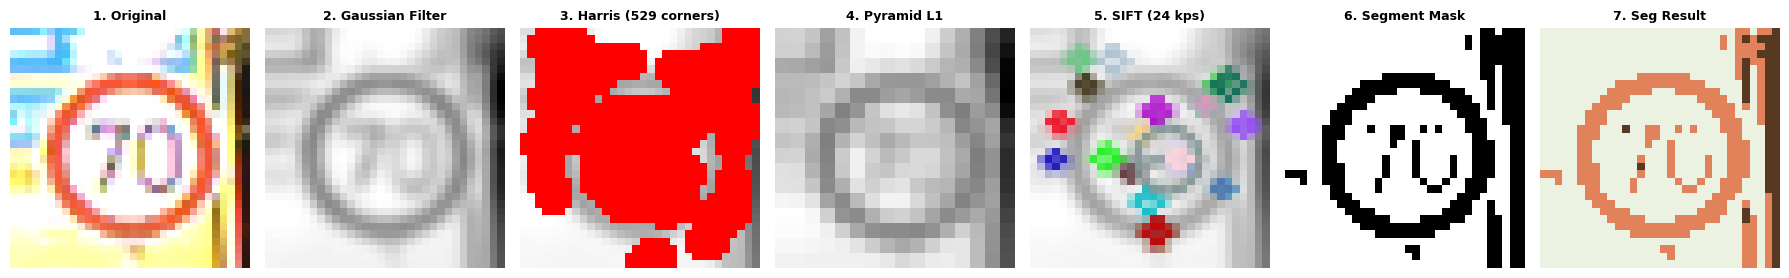

✅ True: Speed 70        Predicted: Speed 70



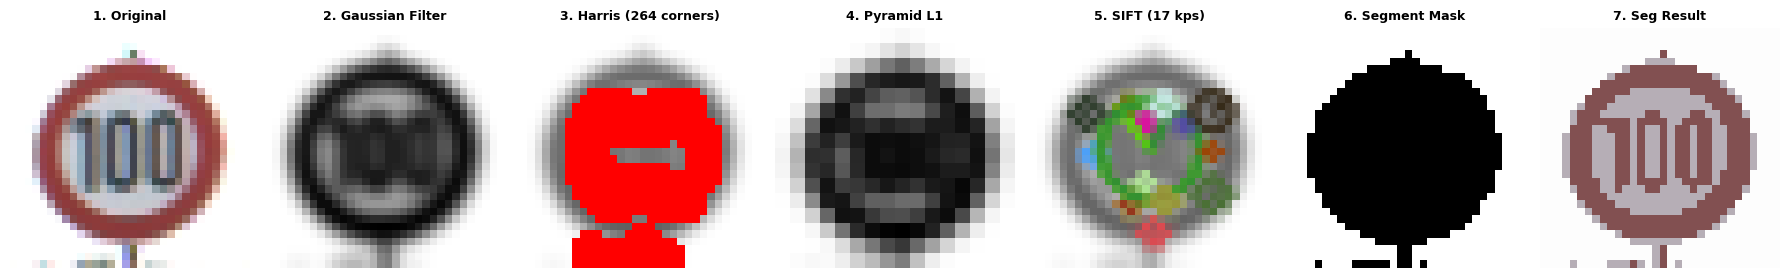

✅ True: Speed 100       Predicted: Speed 100



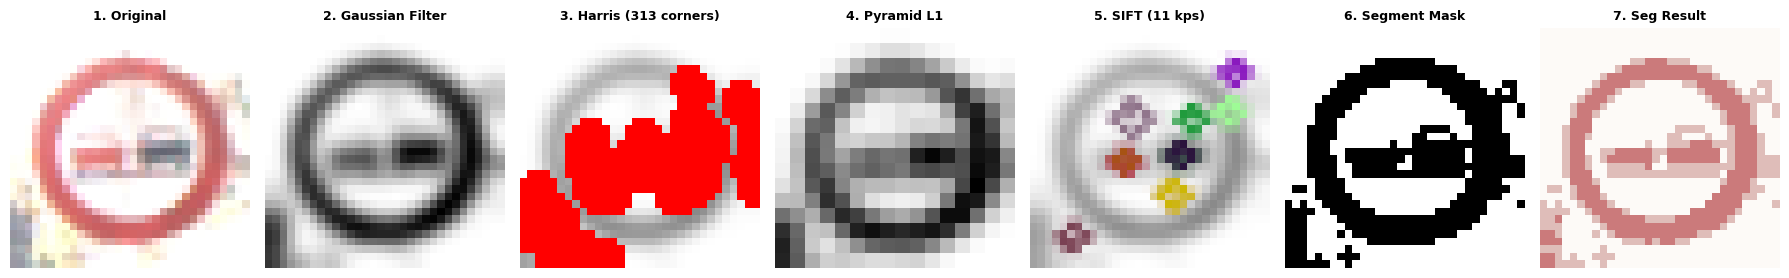

✅ True: No Passing      Predicted: No Passing



In [ ]:
print('=' * 60)
print('  RUNNING FULL INTEGRATED PIPELINE ON TEST SAMPLES')
print('=' * 60)

test_indices = [np.where(labels == c)[0][-1] for c in [0, 2, 4, 7, 9]]
for idx in test_indices:
    true_cls  = labels[idx]
    pred_cls  = full_pipeline(images_raw[idx], nb_clf, scaler)
    match_str = '✅' if pred_cls == true_cls else '❌'
    print(f'{match_str} True: {CLASS_NAMES[true_cls]:<14}  Predicted: {CLASS_NAMES.get(pred_cls, "?")}\n')